In [1]:
import random

import torch
import numpy as np
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt


from neigbhorhoods import CycleNeighborhood
from models import ThreeLayerMLP

In [2]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cpu")
if torch.cuda.is_available():
	device = torch.device("cuda")

    # set seed
	torch.cuda.manual_seed_all(seed)
	torch.backends.cudnn.benchmark = False
	torch.backends.cudnn.deterministic = True

5000


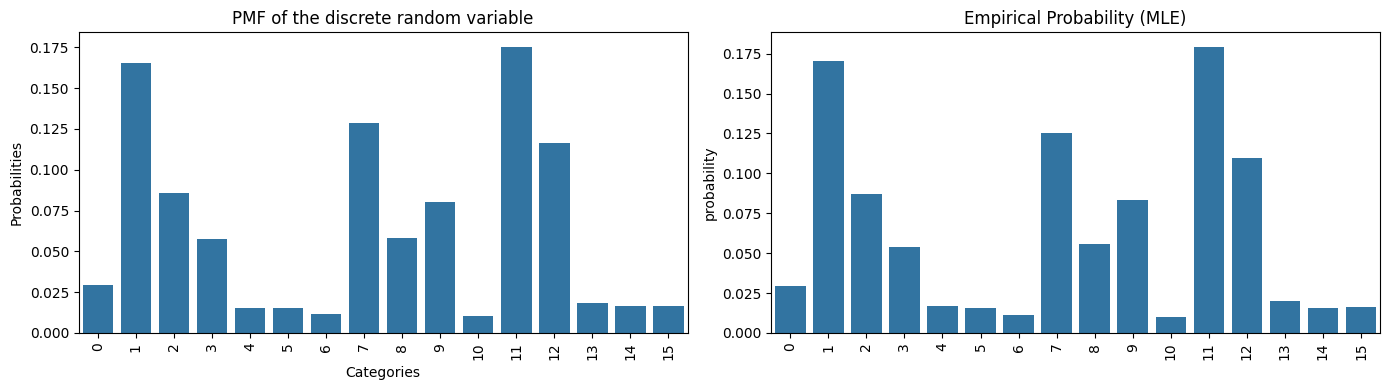

In [3]:
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x))


# according to the paper, we will generate random variable whose support is 16 categories
num_categories = 16
categories = [index for index in range(num_categories)]
# pmf of 16 categories
probs = softmax(np.random.uniform(0, 3, size=(num_categories, )))
pmf = {categories[idx] : probs[idx] for idx in range(16)}

# use the pmf, lets draw 1000 samples. This will be our training dataset as well.
n_samples = 5000
samples = np.random.choice(categories, size=n_samples, replace=True, p=probs).tolist()
print(len(samples))

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- PMF plot ---
sns.barplot(x=categories, y=probs, ax=axes[0])
axes[0].set_xlabel("Categories")
axes[0].set_ylabel("Probabilities")
axes[0].set_title("PMF of the discrete random variable")
axes[0].tick_params(axis='x', rotation=90)

# --- Empirical probability plot ---
sns.countplot(x=sorted(samples), stat="probability", ax=axes[1])
axes[1].set_title("Empirical Probability (MLE)")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [4]:
cyc_neigbh = CycleNeighborhood(categories)

model = ThreeLayerMLP(in_features=1, out_features=cyc_neigbh.num_neighbors, hidden_dim=100)
model.to(device)

ThreeLayerMLP(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=1, bias=True)
  )
)

Let's implement algorithm 1 and algorithm 2 of the paper. This will give us the estimate of loss function.

In [6]:
def training_loop(samples, model, optimizer, NClass, num_categories, num_iterations, device):
    # set in train model
    model.train()

    # set zero grad
    optimizer.zero_grad()

    train_losses = []
    for niter in range(num_iterations):
        # sample a data point from samples
        rand_idx = torch.randint(0, len(samples), size=(1,))

        # x -> will be of shape (1, 1)
        x = samples[rand_idx]
        # get the neighborhoods for this x
        neighbors = NClass.neighborhood[x.item()]
        # get the inverse neighborhood for this x
        neighbors_inv = NClass.inv_neighborhood[x.item()]
        nx, nix = len(neighbors), len(neighbors_inv)
        # sample a neigbhor and sample a inverse neighbor
        rand_n_idx = np.random.randint(0, nx)
        rand_nix_idx = np.random.randint(0, nix)
        selected_inverse_neighbor = neighbors_inv[rand_nix_idx]

		# get the neighbors of inverse neighbor
        inv_neighbors = NClass.neighborhood[selected_inverse_neighbor]
        # for this sampled inverse neighbor, find the index of original sampled data
        index_inv_original = -1
        for index, xp in enumerate(inv_neighbors):
            if xp == x.item():
                index_inv_original = index
                break

        # forward pass (normalize to 0-1)
        x = x.to(torch.float32).to(device)
        xi_tensor = torch.tensor([[selected_inverse_neighbor]], device=device, dtype=torch.float32)
        nout = model(x / num_categories)
        niout = model(xi_tensor / num_categories)

		# calculate the loss
        L1 = nx * torch.mean(nout[:, rand_n_idx] ** 2 + 2 * nout[:, rand_n_idx])
        L2 = 2 * nix * torch.mean(niout[:, index_inv_original])

        loss = L1 - L2
        loss.backward()

        # update
        optimizer.step()
        optimizer.zero_grad()

        # put
        train_losses.append(loss.item())

        # print
        if (niter + 1) % 100 == 0:
            print(f"Iteration = {niter + 1}, sample = {x.item()}, loss = {loss.item()}")

    print("Training Completed")
    return train_losses

In [7]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
train_losses = training_loop(torch.tensor(samples).unsqueeze(-1), model, optimizer, cyc_neigbh, num_categories, 100000, device)

Iteration = 100, sample = 11.0, loss = 0.02020004391670227
Iteration = 200, sample = 11.0, loss = 0.01279476284980774
Iteration = 300, sample = 2.0, loss = -0.0028672516345977783
Iteration = 400, sample = 11.0, loss = -0.07426869124174118
Iteration = 500, sample = 11.0, loss = -0.016659166663885117
Iteration = 600, sample = 7.0, loss = -0.039869774132966995
Iteration = 700, sample = 12.0, loss = -0.0417933315038681
Iteration = 800, sample = 13.0, loss = -0.018032610416412354
Iteration = 900, sample = 3.0, loss = -0.08271226286888123
Iteration = 1000, sample = 15.0, loss = -0.01618160307407379
Iteration = 1100, sample = 2.0, loss = -0.05211639404296875
Iteration = 1200, sample = 3.0, loss = -0.03039705753326416
Iteration = 1300, sample = 4.0, loss = -0.05422576144337654
Iteration = 1400, sample = 2.0, loss = -0.024112790822982788
Iteration = 1500, sample = 9.0, loss = -0.03859429061412811
Iteration = 1600, sample = 7.0, loss = -0.04401908069849014
Iteration = 1700, sample = 12.0, loss =

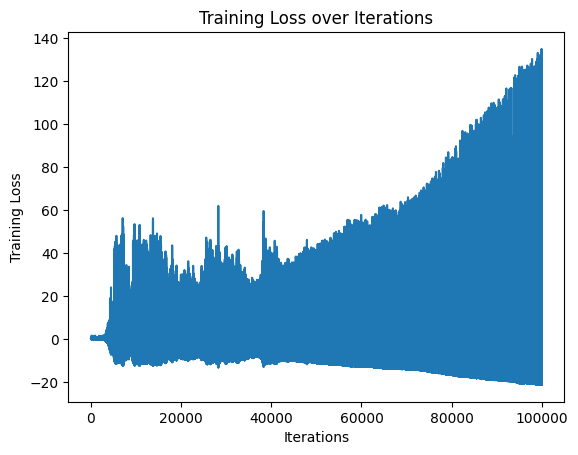

In [8]:
# plot train losses
plt.plot(train_losses)
plt.xlabel("Iterations")
plt.ylabel("Training Loss")
plt.title("Training Loss over Iterations")
plt.show()

Even though the loss function looks terrible, we will just implement the MH algorithm that can sample. Let's hope that it gives correct sample (it's a joke, it will never give correct samples, see the loss curve above)

In [ ]:
def metropolis_sampling(model, num_categories, device, iters=100):
    model.eval()

    # start from a random category
    x0 = np.random.randint(0, num_categories)
    for _ in range(iters):
        # propose a new category